# Computing I Assignment 4
Kwatcho Mahinanda
10/8/2025

In [59]:
import pandas as pd
import plotly.express as px
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import re
import seaborn as sns

### How many distint "bill" identifiers are there?

In [60]:
# Load the dataset
df = pd.read_csv("bills_actions.csv")

#Number of distinct bill identifiers
num_unique_bills = df['bill_number'].nunique()
print(f"Number of distinct bill identifiers: {num_unique_bills}")


Number of distinct bill identifiers: 1331


In [61]:
# Create a new column for a truly unique bill ID
df['bill_id'] = df['bill_type'] + df['bill_number'].astype(str)

# Now, count the unique values in this new column
num_unique_bills = df['bill_id'].nunique()

print(f"Number of distinct bill identifiers: {num_unique_bills}")

Number of distinct bill identifiers: 1494


### What proportion of the rows belong to different categories?

In [62]:
#Proportion of rows by category
category_proportions = df['category'].value_counts(normalize=True).reset_index()
category_proportions.columns = ['category_name', 'proportion']
print("\nProportion of rows by category:")
print(category_proportions)
print(category_proportions["proportion"].sum())



Proportion of rows by category:
                  category_name  proportion
0                     amendment    0.462913
1                    house bill    0.273085
2                   senate bill    0.155616
3              house resolution    0.070845
4             senate resolution    0.018165
5        house joint resolution    0.006661
6   house concurrent resolution    0.006055
7  senate concurrent resolution    0.004239
8       senate joint resolution    0.002422
1.0


### The proportion of rows that belongs to different “main_action” within each category

In [63]:
# Proportion of main_action within each category
main_action_proportions = (
    df.groupby('category')['main_action']
      .value_counts(normalize=True)
      .rename('proportion')
      .reset_index()
)

print("\nProportion of main_action within each category:")
print(main_action_proportions.head())

check_sums = main_action_proportions.groupby("category")["proportion"].sum()
print("\nCheck sums by category:")
print(check_sums)




Proportion of main_action within each category:
     category                               main_action  proportion
0   amendment                   house amendment offered    0.541530
1   amendment             other house amendment actions    0.259647
2   amendment  senate amendment proposed (on the floor)    0.187050
3   amendment            other senate amendment actions    0.011772
4  house bill                       house floor actions    0.778271

Check sums by category:
category
amendment                       1.0
house bill                      1.0
house concurrent resolution     1.0
house joint resolution          1.0
house resolution                1.0
senate bill                     1.0
senate concurrent resolution    1.0
senate joint resolution         1.0
senate resolution               1.0
Name: proportion, dtype: float64


### How many house floor actions are there as part of senate bills (category)?

In [64]:
# Senate bills that mention "house floor" in either 'action' or 'main_action'
mask_category = df['category'].str.lower() == 'senate bill'
mask_house_floor_action = df['action'].str.contains(r'house\s+floor', case=False, na=False)
mask_house_floor_main = df['main_action'].str.contains(r'house\s+floor', case=False, na=False)

# Combine either field that mentions "house floor"
mask_house_floor = mask_category & (mask_house_floor_action | mask_house_floor_main)
senate_house_floor = df.loc[mask_house_floor].copy()

print("Total rows in dataset:", len(df))
print("Number of house floor actions in senate bills:", len(senate_house_floor))


Total rows in dataset: 3303
Number of house floor actions in senate bills: 116


In [65]:
# Filter for Senate Bills
mask_senate = df['category'].str.lower() == 'senate bill'

# Filter for actions that mention House
mask_house = df['action'].str.contains('house', case=False, na=False)

senate_house_actions = df[mask_senate & mask_house]

# Total number of house floor actions as part of senate bills
total_actions = len(senate_house_actions)
print("Total House floor actions in Senate Bills:", total_actions)


Total House floor actions in Senate Bills: 4


### What proportion of these actions were suspended? What proportion of these actions were suspended as amended?

In [66]:
# Proportion suspended
suspended_mask = senate_house_actions['action'].str.contains('suspended', case=False, na=False)
suspended_count = suspended_mask.sum()
print("Proportion suspended:", suspended_count / total_actions)

# Proportion suspended as amended
suspended_amended_mask = senate_house_actions['action'].str.contains('suspended as amended', case=False, na=False)
suspended_amended_count = suspended_amended_mask.sum()
print("Proportion suspended as amended:", suspended_amended_count / total_actions)


Proportion suspended: 0.0
Proportion suspended as amended: 0.0


In [67]:
# Regex pattern for titles + names
pattern = r'\b(Mr|Ms|Mrs|Miss|Dr)\.?\s+[A-Z][a-z]+'

# Extract all names from actions
senate_house_actions['names'] = senate_house_actions['action'].apply(lambda x: re.findall(pattern, x) if pd.notnull(x) else [])

# Explode to have one row per person mentioned
names_exploded = senate_house_actions.explode('names')

# Count number of bills mentioning each person
person_counts = names_exploded.groupby('names').size().reset_index(name='bill_count')
person_counts = person_counts.sort_values(by='bill_count', ascending=False)
print(person_counts.head(10))

  names  bill_count
0    Mr           4


C:\Users\kwatcho\AppData\Local\Temp\ipykernel_20988\1824505603.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  senate_house_actions['names'] = senate_house_actions['action'].apply(lambda x: re.findall(pattern, x) if pd.notnull(x) else [])


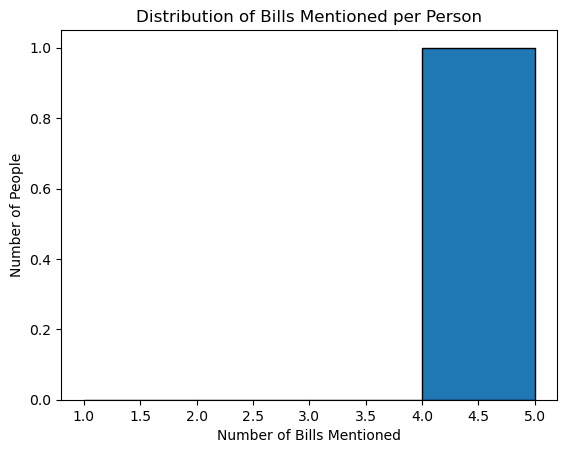

In [68]:
plt.hist(person_counts['bill_count'], bins=range(1, person_counts['bill_count'].max()+2), edgecolor='black')
plt.xlabel("Number of Bills Mentioned")
plt.ylabel("Number of People")
plt.title("Distribution of Bills Mentioned per Person")
plt.show()


### Find how many mention "senate amendment proposed (on the floor)'

In [75]:
# Filter for "senate amendment proposed (on the floor)" in main_action
amendment_actions = df[df['main_action'].str.contains(
    'senate amendment proposed \(on the floor\)', case=False, na=False
)].copy()

print("Number of bills with 'senate amendment proposed (on the floor)':", len(amendment_actions))


Number of bills with 'senate amendment proposed (on the floor)': 286


### Extract senator names

In [76]:
# Extract all senator mentions per bill
amendment_actions['senators'] = amendment_actions['main_action'].str.findall(r'Senator \S+|Sen\. \S+')

# Count number of senators per bill
amendment_actions['num_senators'] = amendment_actions['senators'].apply(len)

# Assign first and second senator mentioned
amendment_actions['Senator 1'] = amendment_actions['senators'].apply(lambda x: x[0] if len(x) >= 1 else None)
amendment_actions['Senator 2'] = amendment_actions['senators'].apply(lambda x: x[1] if len(x) >= 2 else None)

# Keep relevant columns
senator_dataset = amendment_actions[['main_action', 'num_senators', 'Senator 1', 'Senator 2']]
display(senator_dataset.head(10))


,main_action,num_senators,Senator 1,Senator 2
0,senate amendment proposed (on the floor),0,None,None
1,senate amendment proposed (on the floor),0,None,None
2,senate amendment proposed (on the floor),0,None,None
8,senate amendment proposed (on the floor),0,None,None
11,senate amendment proposed (on the floor),0,None,None
14,senate amendment proposed (on the floor),0,None,None
17,senate amendment proposed (on the floor),0,None,None
18,senate amendment proposed (on the floor),0,None,None
20,senate amendment proposed (on the floor),0,None,None
26,senate amendment proposed (on the floor),0,None,None


### Create Senator 1 and Senator 2 columns

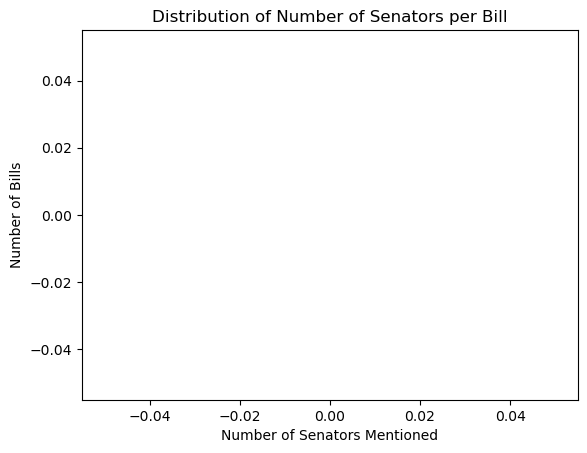

In [77]:
plt.hist(senator_dataset['num_senators'], bins=range(1, senator_dataset['num_senators'].max() + 2), edgecolor='black')
plt.xlabel("Number of Senators Mentioned")
plt.ylabel("Number of Bills")
plt.title("Distribution of Number of Senators per Bill")
plt.show()
